## Семинар 5: "Улучшение сходимости нейросетей"

ФИО:

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
%matplotlib inline

## Описание задания:
Вам необходимо реализовать оставшиеся методы из лекции и сравнить их на примере из семинара.

## Задание разделено на следующие части:
1. Реализация Xavier **(1 балл)**

2.1 Реализация DropConnect **(1 балл)**

2.2 Сравнение обучения при использовании Dropout и DropConnect **(1 балл)**

3.1 Реализация LayerNorm **(1 балл)**

3.2 Сравнение обучения при использовании BatchNorm и LayerNorm **(1 балл)**

## Срок выполнения задания:
Данное задание можно сдать без штрафов до 16 октября.


### Часть 1: Инициализация весов

Будем использовать MNIST для обучения:

In [2]:
# Dataloader
def to_numpy(x): return x.numpy()


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = MNIST('.', train=True, download=True, transform=transform)
test_dataset = MNIST('.', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.64MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 162kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.22MB/s]


In [3]:
images_train, labels_train = next(iter(train_loader))

In [4]:
# Usage example:
for X, y in train_loader:
    X = X.view(X.size(0), -1)
    X = X.numpy()  # Converts torch.Tensor to numpy array
    y = y.numpy()
    break

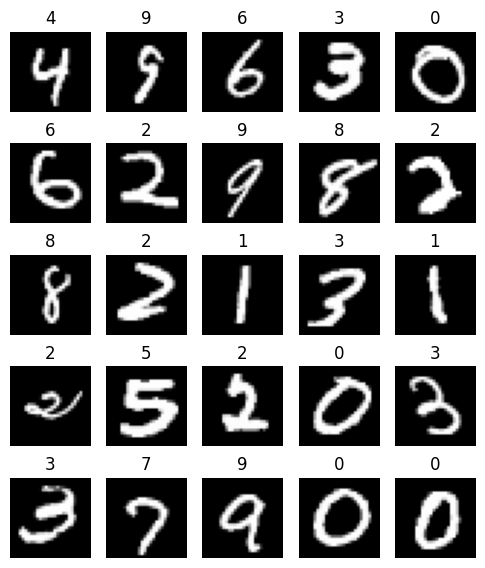

In [6]:
plt.figure(figsize=(6, 7))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.title(y[i])
    plt.axis('off')

In [ ]:
def init_layer(layer, mean=0, std=1):
    # Тут надо быть аккуратным — можно случайно создать копию и менять значения у копии
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    weight.normal_(mean=0, std=std)


def forward_hook(self, input_, output):
    std = input_[0].std().item()
    print('forward', std)


def backward_hook(self, grad_input, grad_output):
    std = grad_input[0].std().item()
    print('backward', std)

На вход передаем изображение 28x28, на выходе -- вероятности 10 классов.

In [12]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_layer(layer_1)
init_layer(layer_2)

Соберем все вместе, используя ReLU в качестве функции активации:

In [14]:
layer_1 = nn.Linear(28*28, 256)
layer_2 = nn.Linear(256, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_layer(layer_1, 0, 2 / 256)
init_layer(layer_2, 0, 2 / 10)

In [15]:
network = nn.Sequential(
    layer_1,
    nn.ReLU(),
    layer_2
)

n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 0.9932380318641663
forward 0.12637031078338623
backward 0.02828427031636238
backward 0.035433970391750336


#### 1.1 Реализуйте инициализацию Xavier. Сравните ее с He, которая была реализована на семинаре, сделайте выводы. Учтите, что для Xavier необходимо использовать функцию активации nn.Tanh(). **(1 балл)**

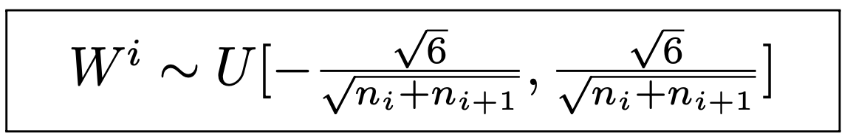

In [30]:
@torch.no_grad()
def init_layer_uniform(layer, a, b):
    layer.weight.uniform_(a, b)
    layer.bias.zero_()

In [31]:
layer_1 = nn.Linear(28*28, 256)
layer_2 = nn.Linear(256, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_layer_uniform(layer_1, -np.sqrt(6) / np.sqrt(28 * 28 *
                   + 256), np.sqrt(6) / np.sqrt(28 * 28 + 256))
init_layer_uniform(layer_2, -np.sqrt(6) / np.sqrt(256 + 10),
                   np.sqrt(6) / np.sqrt(256 + 10))

In [32]:
network = nn.Sequential(
    layer_1,
    nn.Tanh(),
    layer_2
)

n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 0.9932380318641663
forward 0.895633339881897
backward 0.02828427031636238
backward 0.006228315178304911


## Часть 2: DropConnect

#### 2.1 Реализуйте DropConnect по следующему шаблону: **(1 балл)**

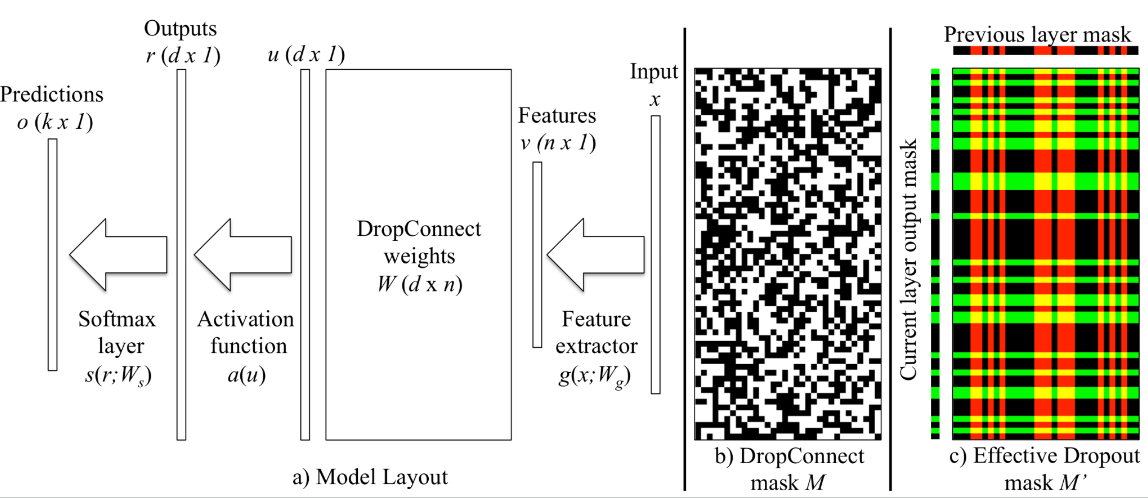

In [ ]:
# полезная функция: .bernoulli_(p)
# не забывайте делать requires_grad=False у маски
# помните, что в вычислениях должны участвовать Variable, а не тензоры

class DropConnect(nn.Module):
    def __init__(self, input_dim, output_dim, p=0.5):
        super(DropConnect, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.p = p

    def forward(self, x):
        W = self.linear.weight
        b = self.linear.bias

        if self.training and self.p > 0.0:
            with torch.no_grad():
                mask = torch.bernoulli(torch.full_like(W, (1.0 - self.p)))

            W_eff = W * mask / (1.0 - self.p)
        else:
            W_eff = W

        return F.linear(x, W_eff, b)

In [ ]:
class Dropout(nn.Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.empty_like(x).bernoulli_(1.0 - self.p)

            return (x * mask) / (1.0 - self.p)
        else:
            return x

Основа для сети, которую будем обучать:

In [35]:
class TestNetwork(nn.Module):
    def __init__(self, final_part):
        super().__init__()

        channels = 1

        self.conv_layers = nn.Sequential(
            nn.Conv2d(channels, 2, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(2, 4, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
        )

        # input_size = 7 * 7 * 4 = 196
        self.flatten = nn.Flatten()

        self.final_part = final_part

        self.log_softmax = nn.LogSoftmax(1)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.final_part(x)
        return self.log_softmax(x)

Добавим несколько слоев в конец сети:

In [49]:
layers = [
    DropConnect(196, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
]

In [50]:
layers_dropout = [
    nn.Linear(196, 64),
    Dropout(),
    nn.ReLU(),
    nn.Linear(64, 10)
]

In [51]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

Обучим получившуюся сеть:

In [52]:
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(X), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
        epoch, np.mean(losses)))

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.310980
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.723983
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.613122
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.577081
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.664294
Test Epoch: 0	Loss: 0.377440
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.575766
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.443739
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.398802
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.432019
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.496102
Test Epoch: 1	Loss: 0.307966
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.471054
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.354647
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.348786
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.259276
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.406420
Test Epoch: 2	Loss: 0.237384
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.301895
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.244843
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.173452
Train Epoch: 3 [38400/60000 (64%)


#### 2.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Dropout между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и DropConnect вместо всех линейных слоев


In [53]:
network = TestNetwork(nn.Sequential(*layers_dropout))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(X), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
        epoch, np.mean(losses)))

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.311454
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.129832
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.605827
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.505388
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.279853
Test Epoch: 0	Loss: 0.253666
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.602014
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.322242
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.385021
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.406439
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.293429
Test Epoch: 1	Loss: 0.158929
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.223610
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.199749
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.287140
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.203633
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.196174
Test Epoch: 2	Loss: 0.127970
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.247382
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.174564
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.205314
Train Epoch: 3 [38400/60000 (64%)

### Часть 3: Batch Normalization

Наконец, давайте рассмотрим Batch Normalization. Этот слой вычитает среднее и делит на стандартное отклонение. Среднее и дисперсия вычисляются по батчу независимо для каждого нейрона. У этого слоя есть две важные проблемы: его нельзя использовать при обучении с размером батча 1 и он делает элементы батча зависимыми. Давайте реализуем аналог батч нормализации: <a href=https://arxiv.org/pdf/1607.06450.pdf>Layer normalization</a>. В layer normalization среднее и дисперсия вычисляются по активациям нейронов, независимо для каждого объекта.

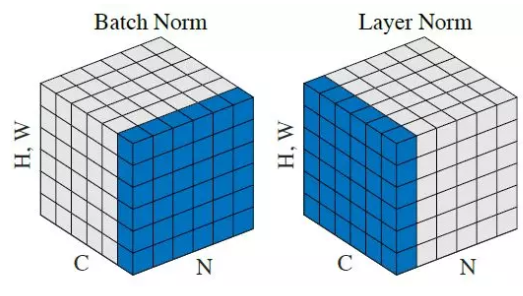

#### 3.1 Реализуйте Layer Normalization **(1 балл)**

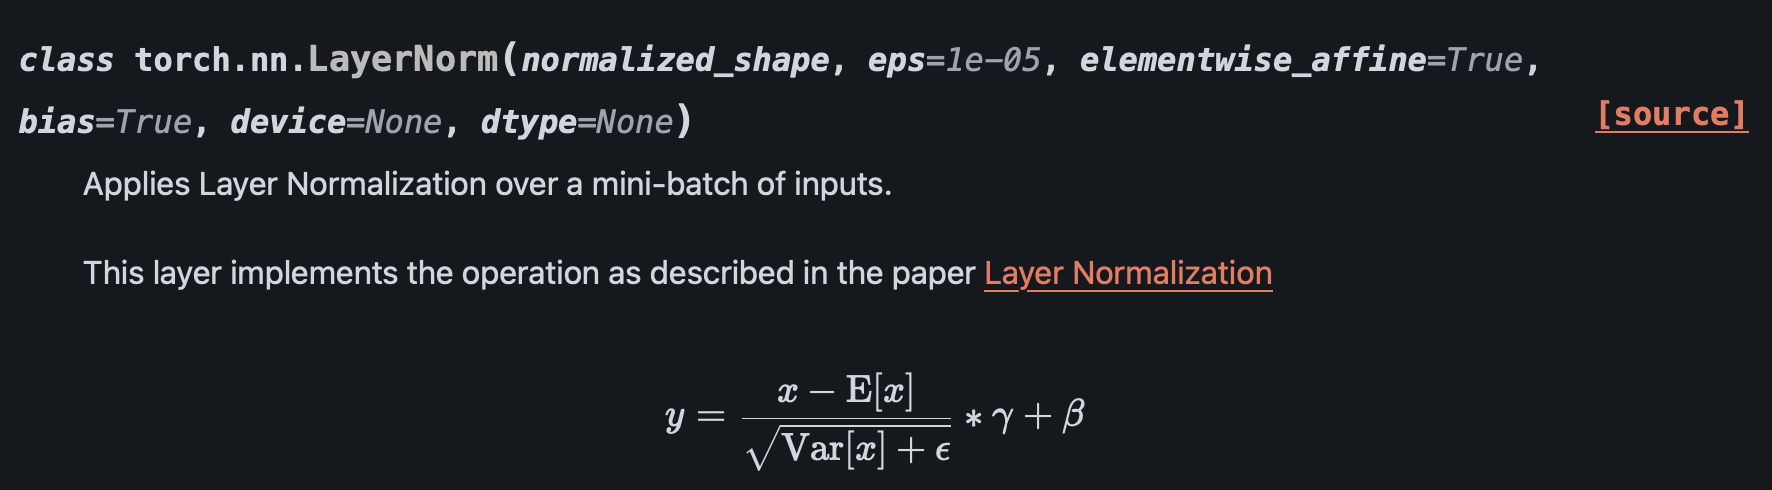

In [59]:
# полезные функции: .std(dim), .mean(dim)

class LayerNormalization(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5, elementwise_affine=True, bias=True):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        self.bias = bias

        if self.elementwise_affine:
            self.gamma = nn.Parameter(torch.ones(normalized_shape))
            self.beta = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        if self.elementwise_affine:
            return self.gamma * x_norm + self.beta

        return x_norm

#### 3.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Batch normalization между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Layer normalization между всеми слоями

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.338509
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.251281
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.138074
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.129025
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.118773
Test Epoch: 0	Loss: 0.090901
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.104928
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.084417
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.083040
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.080300
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.088755
Test Epoch: 1	Loss: 0.073039
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.063208
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.102725
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.071989
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.063795
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.051403
Test Epoch: 2	Loss: 0.067753
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.020048
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.048393
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.032073
Train Epoch: 3 [38400/60000 (64%)

Text(0, 0.5, 'Loss')

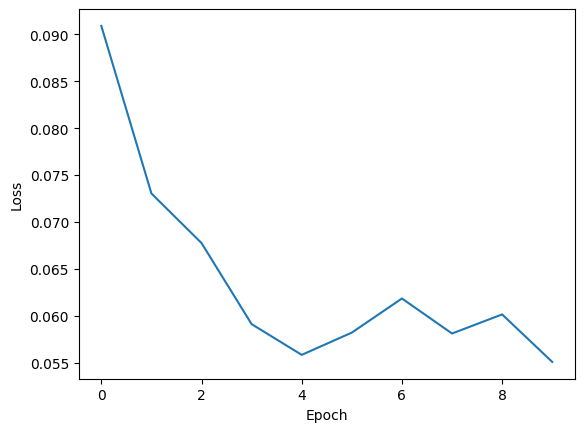

In [57]:
layers = [
    nn.Linear(196, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 10)
]

network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()
loss_epoch = []
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(X), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
        epoch, np.mean(losses)))
    loss_epoch.append(np.mean(losses))

plt.plot(loss_epoch)
plt.xlabel('Epoch')
plt.ylabel('Loss')

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.406499
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.244631
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.194024
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.171563
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.097397
Test Epoch: 0	Loss: 0.107101
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.080205
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.061540
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.074171
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.053059
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.126720
Test Epoch: 1	Loss: 0.072242
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.035124
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.049340
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.039969
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.158346
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.086412
Test Epoch: 2	Loss: 0.061013
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.071278
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.055923
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.033921
Train Epoch: 3 [38400/60000 (64%)

Text(0, 0.5, 'Loss')

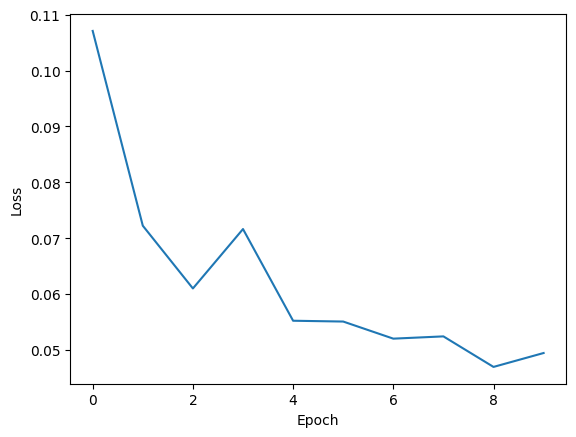

In [60]:
layers = [
    nn.Linear(196, 128),
    LayerNormalization(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    LayerNormalization(128),
    nn.ReLU(),
    nn.Linear(128, 10)
]

network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()
loss_epoch = []
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(X), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
        epoch, np.mean(losses)))
    loss_epoch.append(np.mean(losses))

plt.plot(loss_epoch)
plt.xlabel('Epoch')
plt.ylabel('Loss')